# Reconstruction

Reconstruction is the main stage of the `pointcloud` module. It processes the keyframes selected from `preproc`, creating a camera per frame, and uses a specified method to create a pointcloud.

This tutorial illustrates how to reconstruct the tutorial scene from (1) a feedforward model (VGGT Omega) and (2) a Structure-from-Motion (SfM) model. Reconstructions are then validated by testing the viewpoint agreement of the derived camera poses.

In [1]:
import contextlib
import io
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pycolmap

from collab_splats.geometry.metrics import compute_reconstruction_quality
from collab_splats.pointcloud.sfm import InstantSfMCreator
from collab_splats.pointcloud.utils import clean_pointcloud
from collab_splats.utils.visualization import (
    camera_view,
    pointcloud_to_polydata,
    visualize_splat,
)

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud", "reconstruction_quality_report")

## 1. Feedforward reconstruction

A feedforward model (here VGGT-Omega) predicts a depth map and a camera for every keyframe in
one network pass. The pipeline already ran it for this scene, so the page loads the result.
Each camera has two sets of intrinsics: one for the full-size frame and one for the smaller grid
the model's depth lives on.

In [2]:
result = scene.result
print(f"{len(result.points):,} points, {len(result.image_paths)} cameras")

500,000 points, 96 cameras


The point cloud seen from the side, thinned for display. Cameras are colored by time:

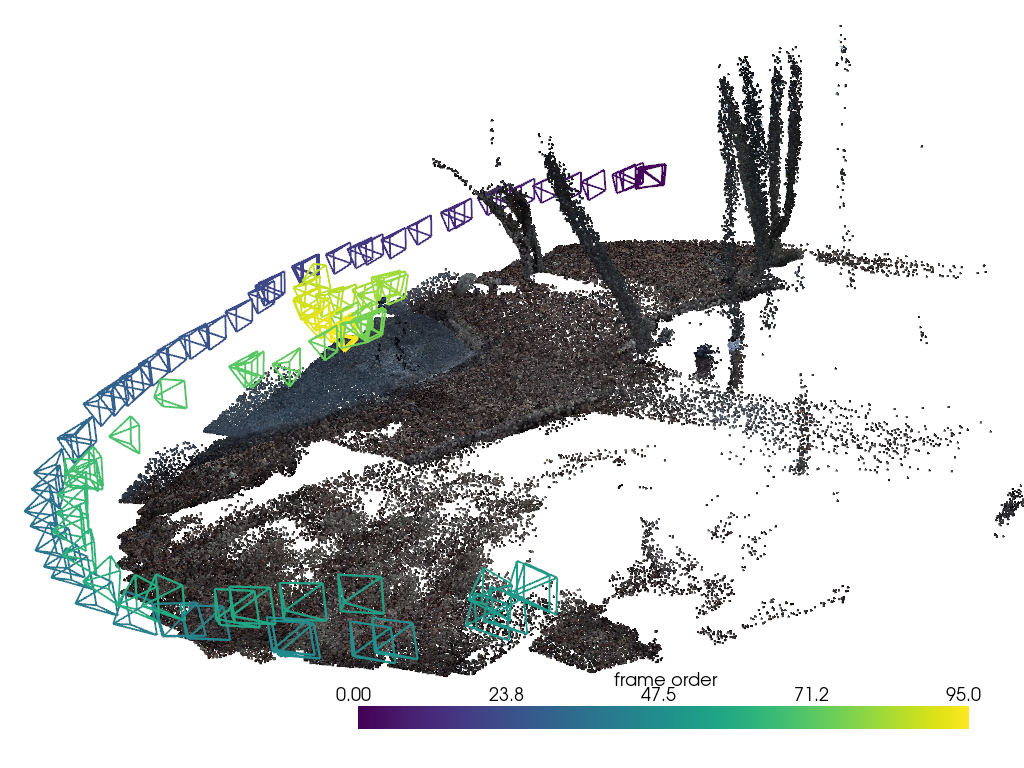

In [3]:
# Thin the cloud for display
display_cloud = clean_pointcloud(result, remove_outliers=False, max_points=200_000)
cloud = pointcloud_to_polydata(display_cloud.points, RGB=display_cloud.colors)

# Frustum size from the scene size; feedforward units are arbitrary
lo, hi = np.percentile(display_cloud.points, [5, 95], axis=0)
size = np.linalg.norm(hi - lo)

plotter = visualize_splat(
    cloud,
    display_cloud.extrinsics,
    camera_kwargs={"scale": 0.005 * size, "n_poses": 1, "line_width": 2},
    viz_kwargs=camera_view(display_cloud.extrinsics, display_cloud.points),
)
plotter.show()

The cameras should trace the walked path from dark (start) to yellow (end), and the points
should form clear surfaces in front of them.

## 2. Structure from motion

Structure from motion (InstantSfM) matches features between frames and solves all cameras
together. Its point cloud is sparse, so the creator adds a depth map per frame from
Video-Depth-Anything, scaled to fit the SfM points. The result has the same form as the
feedforward one. SfM drops frames it cannot match, so it needs more overlap between keyframes.

In [4]:
sfm_dir = work_dir("reconstruction")
sfm = InstantSfMCreator(random_seed=0)

# Hide InstantSfM and COLMAP progress output
pycolmap.logging.minloglevel = 2
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    sfm_result = sfm.create_pointcloud(scene.images_dir, sfm_dir)

# How many frames SfM placed, and the scale that fit each depth map to the SfM points
scales = np.asarray(sfm.attrs["depth_scales"])
print(f"{sfm.attrs['registered_frames']} of {sfm.attrs['total_frames']} frames registered")
print(f"depth scale: median {np.median(scales):.2f}, range {scales.min():.2f}-{scales.max():.2f}")

77 of 96 frames registered
depth scale: median 5.02, range 4.30-6.77


The depth scale should be about the same for every frame. A wide range means the depth model and
SfM disagree about the scene's shape, not just its size.

## 3. Judging a reconstruction

There is no ground truth, so the views check each other: each frame's depth is projected into
the other frames, and where two views see the same surface their depths should match. The
`reconstruction_quality_report` stage measures:

- multiview agreement: share of a frame's pixels whose depth another view confirms within 5%.
  1 means every pixel is confirmed.
- relative depth residual: (depth seen by view B − depth predicted from view A) / depth.
  0 means the views agree; 0.1 means 10% off.
- parallax: angle between two views of the same point. Small parallax pins depth poorly.

The five frames with the lowest agreement:

In [5]:
report = json.loads(scene.outputs["reconstruction_quality_report"].read_text())
ff_frames = pd.DataFrame(report["frames"])
columns = ["frame_idx", "multiview_agreement", "median_abs_rel_depth_error"]
display(ff_frames.sort_values("multiview_agreement")[columns].head(5).round(3))

,frame_idx,multiview_agreement,median_abs_rel_depth_error
65,1468,0.732,0.033
44,949,0.889,0.030
40,859,0.892,0.024
41,884,0.898,0.023
0,0,0.901,0.022


The same measurements for the SfM result, computed directly from its arrays:

In [6]:
sfm_names = [path.name for path in sfm_result.image_paths]
sfm_tables = compute_reconstruction_quality(
    sfm_result.depth,
    sfm_result.model_intrinsics,
    sfm_result.intrinsics,
    sfm_result.extrinsics,
    sfm_result.original_coords,
    sfm_names,
    sfm_result.confidence,
    None,
)

Both routes side by side:

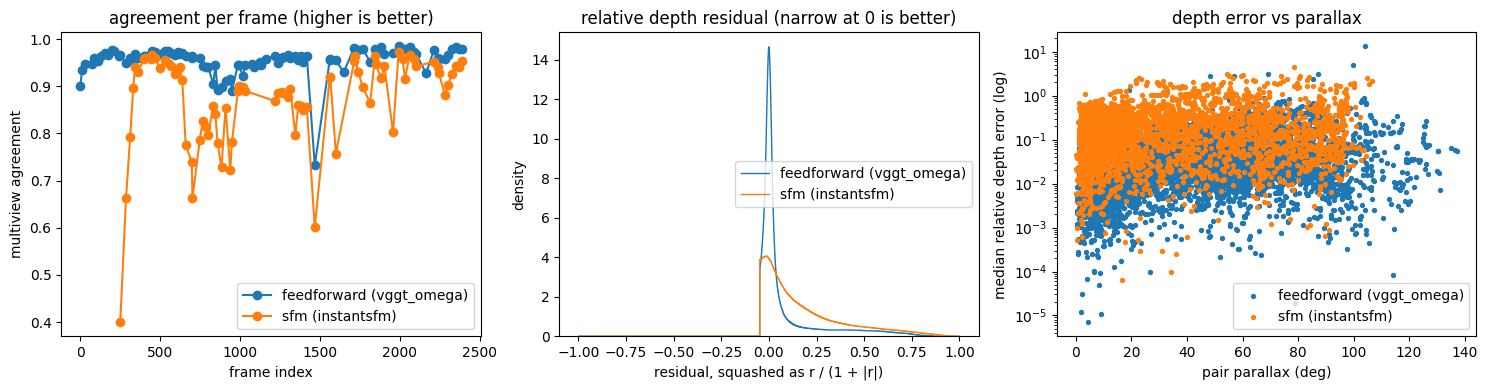

In [7]:
routes = {"feedforward (vggt_omega)": report, "sfm (instantsfm)": sfm_tables}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for label, tables in routes.items():
    frames_df = pd.DataFrame(tables["frames"])
    pairs_df = pd.DataFrame(tables["depth_pairs"])

    # Agreement per frame, against the source frame index
    axes[0].plot(frames_df["frame_idx"], frames_df["multiview_agreement"], "o-", label=label)

    # Residual histogram as a density, since the routes see different pixel counts
    hist = tables["depth_residual_histogram"]
    counts = np.asarray(hist["counts"])
    edges = np.asarray(hist["bin_edges"])
    axes[1].stairs(counts / counts.sum() / np.diff(edges), edges, label=label)

    # Depth error of each frame pair against its parallax
    axes[2].scatter(
        pairs_df["median_parallax_deg"], pairs_df["median_rel_depth_error"], s=8, label=label
    )

axes[0].set(
    title="agreement per frame (higher is better)",
    xlabel="frame index",
    ylabel="multiview agreement",
)
axes[1].set(
    title="relative depth residual (narrow at 0 is better)",
    xlabel="residual, squashed as r / (1 + |r|)",
    ylabel="density",
)
axes[2].set(
    title="depth error vs parallax",
    xlabel="pair parallax (deg)",
    ylabel="median relative depth error (log)",
    yscale="log",
)

for ax in axes:
    ax.legend()

plt.tight_layout()

How to read it:

- Agreement near 1 and a narrow histogram: the views confirm each other.
- One frame with low agreement: usually a bad camera pose.
- Large error at small parallax is expected; large error at large parallax is a real problem.

## In a pipeline run

The `pointcloud` stage picks the route; the `reconstruction_quality_report` stage writes the
report next to `pointcloud.zarr`. SfM is experimental.

```yaml
pointcloud:
  method: feedforward     # feedforward | sfm
  backend: vggt_omega     # vggt_omega | vggtx | mapanything | loger
                          # sfm: instantsfm | colmap | hloc
  instantsfm:
    random_seed: 0
reconstruction_quality_report:
  min_pair_overlap: 0.0   # 0 keeps every ordered pair
```